# Title: Answering Questions from Survey Results
# Name: Maxwell Yung
# Date: 3/2/25

First, we need to read in the cleaned CSV from part 2

In [2]:
import pandas as pd
datafile = "cleaned.csv"
df = pd.read_csv(datafile)

In [3]:
df.columns

Index(['Unnamed: 0', 'hs_class', 'ap_class', 'dual_enrollment',
       'interest_level', 'current_course', 'enrichment', 'curiosity',
       'degree_program', 'age', 'web', 'cybersecurity', 'apps', 'analytics',
       'ml_ai', 'programming', 'gamedev', 'hardware'],
      dtype='object')

### Now, we answer the questions with the cleaned dataset

Using matplotlib will be useful for graphing out answers

In [3]:
import matplotlib.pyplot as plt

Question 1: Are students that have taken a computing class prior to their CCM education more likely to voluntarily take a computing class at CCM? (hs_class, ap_class, dual_enrollment, interest_level) *didn't do this one

Question 2: Which class is the most likely to be taken for someone's passion (personal enrichment or curiosity)? (current_course, enrichment, curiosity)

Answer: CMP 101 is the most engaging class, leading to the highest rating of enrichment and curiosity

In [35]:
df['enrichment'] = df['enrichment'].map({'Yes': 1, 'No': 0}) #shout out to copilot to convert yes/no values into binary
df['curiosity']  = df['curiosity'].map({'Yes': 1, 'No': 0})

df.groupby('current_course')[['enrichment','curiosity']].mean()

,enrichment,curiosity
current_course,,
CMP 101 Computer Information Literacy,0.590909,0.727273
CMP 126 Computer Technology and Applications,0.466667,0.400000
CMP 135 Computer Concepts with Applications,0.525000,0.475000


Question 3: Which programs have the most students who are enthusiastic about computer science? (interest_level, degree_program)

Answer: Biology has the highest average interest, followed by early childhood education. Nursing NOT from CCM has the least interest

<BarContainer object of 23 artists>

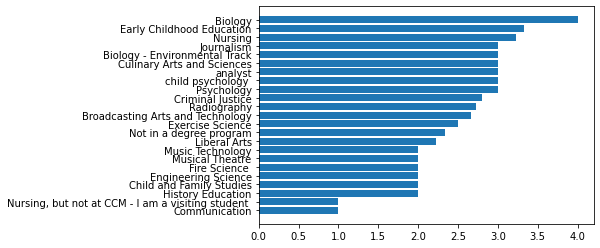

In [45]:
avg = df.groupby('degree_program').interest_level.mean().sort_values()
x = avg.index
y = avg.values
plt.barh(x, y)

In [16]:
df.groupby('degree_program').interest_level.mean().sort_values(ascending=False) #easier way to see values

degree_program
Biology                                               4.000000
Early Childhood Education                             3.333333
Nursing                                               3.222222
analyst                                               3.000000
Psychology                                            3.000000
Journalism                                            3.000000
Biology - Environmental Track                         3.000000
child psychology                                      3.000000
Culinary Arts and Sciences                            3.000000
Criminal Justice                                      2.800000
Radiography                                           2.730769
Broadcasting Arts and Technology                      2.666667
Exercise Science                                      2.500000
Not in a degree program                               2.333333
Liberal Arts                                          2.222222
Engineering Science                     

Question 4: Which specific computer science classes have the most interest? (web, cybersecurity, apps, analytics, ml_ai, programming, gamedev, hardware, interest_level)

Answer: It looks like ml_ai sparks the most interest, with programming and hardware being close seconds.

In [42]:
q4 = ['web', 'cybersecurity', 'apps', 'analytics', 'ml_ai', 'programming', 'gamedev', 'hardware']
df.groupby(q4).interest_level.mean().sort_values(ascending=False) #interesting way to look at all the combinations (?)

web  cybersecurity  apps  analytics  ml_ai  programming  gamedev  hardware
Yes  Yes            No    Yes        No     Yes          No       Yes         5.00000
                    Yes   Yes        Yes    Yes          No       Yes         5.00000
No   Yes            No    No         Yes    No           Yes      No          5.00000
Yes  No             No    No         Yes    Yes          No       No          5.00000
No   No             No    No         Yes    No           No       Yes         5.00000
     Yes            No    Yes        Yes    Yes          Yes      Yes         5.00000
Yes  Yes            Yes   Yes        Yes    Yes          Yes      Yes         4.50000
     No             Yes   No         Yes    Yes          Yes      Yes         4.50000
     Yes            Yes   No         Yes    No           No       No          4.00000
No   Yes            Yes   Yes        Yes    Yes          Yes      Yes         4.00000
                    No    Yes        No     No           Yes     

That's an interesting output, let's try to view this as a table

In [4]:
df['web'] = df['web'].map({'Yes': 1, 'No': 0}) #shout out to copilot to convert yes/no values into binary
df['cybersecurity']  = df['cybersecurity'].map({'Yes': 1, 'No': 0})
df['apps']  = df['apps'].map({'Yes': 1, 'No': 0})
df['analytics']  = df['analytics'].map({'Yes': 1, 'No': 0})
df['ml_ai']  = df['ml_ai'].map({'Yes': 1, 'No': 0})
df['programming']  = df['programming'].map({'Yes': 1, 'No': 0})
df['gamedev']  = df['gamedev'].map({'Yes': 1, 'No': 0})
df['hardware']  = df['hardware'].map({'Yes': 1, 'No': 0})
df.groupby('interest_level')[['web','cybersecurity','apps','analytics','curiosity','ml_ai','programming','gamedev','hardware']].mean()

,web,cybersecurity,apps,analytics,ml_ai,programming,gamedev,hardware
interest_level,,,,,,,,
1,0.058824,0.058824,0.058824,0.000000,0.117647,0.000000,0.117647,0.000000
2,0.185185,0.148148,0.111111,0.222222,0.148148,0.148148,0.148148,0.148148
3,0.235294,0.500000,0.382353,0.235294,0.294118,0.264706,0.382353,0.264706
4,0.500000,0.666667,0.666667,0.500000,0.833333,0.500000,0.833333,0.500000
5,0.625000,0.625000,0.375000,0.500000,0.875000,0.750000,0.500000,0.750000


Question 5: What age group is the least enthusiastic about computer science? (age, interest_level)

Answer: The bar graph indicates that the age group with the least interest is 19-20

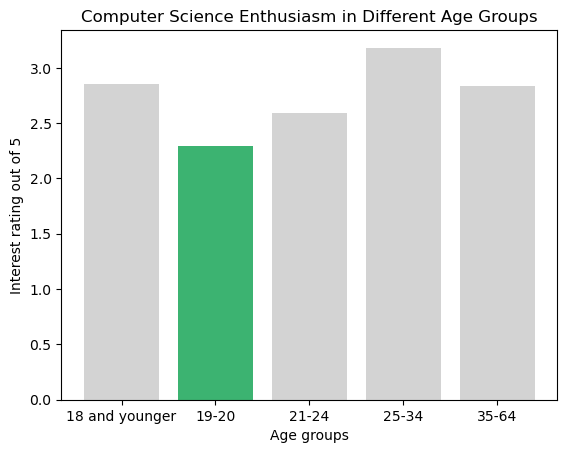

In [9]:
avg = df.groupby('age').interest_level.mean() #thank you copilot for helping assign x/y
x = avg.index
y = avg.values
colors = ['mediumseagreen' if val < 2.5 else 'lightgrey' for val in avg.values]
plt.bar(x, y, color=colors)
plt.title("Computer Science Enthusiasm in Different Age Groups")
plt.xlabel("Age groups")
plt.ylabel("Interest rating out of 5")
plt.show()